In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

In [3]:
X,y=make_circles(n_samples=500,factor=0.1,noise=0.35,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [4]:
X.shape

(500, 2)

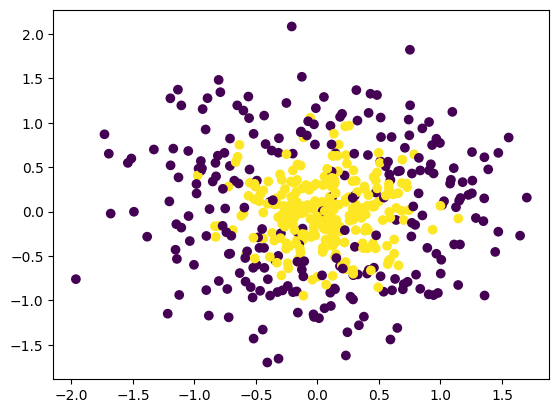

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
from sklearn.tree import DecisionTreeClassifier

In [8]:
dtree=DecisionTreeClassifier(random_state=42)
dtree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


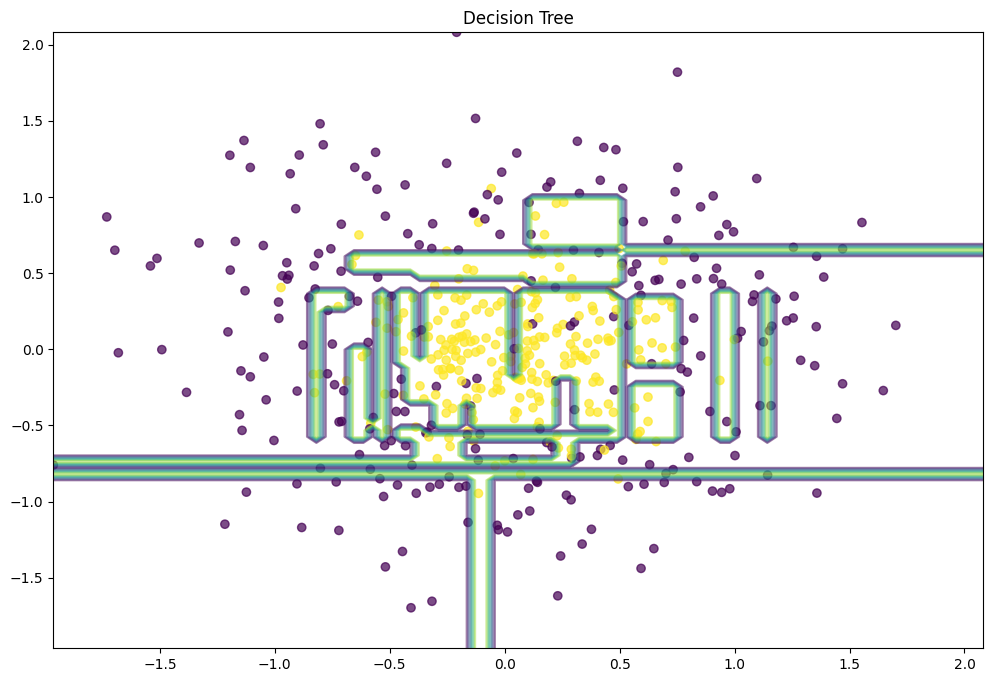

In [35]:
plt.figure(figsize=(12,8))
x_range=np.linspace(X.min(),X.max(),100)
xx1,xx2=np.meshgrid(x_range,x_range)
y_hat=dtree.predict(np.c_[xx1.ravel(),xx2.ravel()])
y_hat=y_hat.reshape(xx1.shape)
plt.contour(xx1,xx2,y_hat,alpha=0.5)
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis',alpha=.7)
plt.title("Decision Tree")
plt.show()

<Figure size 1200x800 with 0 Axes>

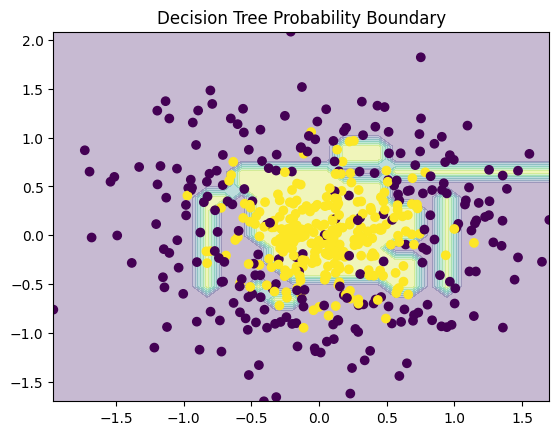

In [52]:
from sklearn.inspection import DecisionBoundaryDisplay
plt.figure(figsize=(12, 8))

DecisionBoundaryDisplay.from_estimator(
    dtree,
    X,
    response_method="predict_proba",
    class_of_interest=1,
    cmap="viridis",
    grid_resolution=30, 
    eps=0.0000, 
    alpha=0.3
)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="viridis",

)

plt.title("Decision Tree Probability Boundary")
plt.show()

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
rf=RandomForestClassifier(n_estimators=500,random_state=42)
rf.fit(X_train,y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<Figure size 1000x700 with 0 Axes>

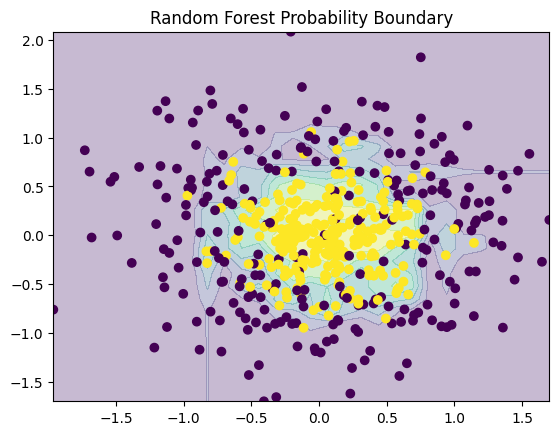

In [51]:
plt.figure(figsize=(10, 7))

DecisionBoundaryDisplay.from_estimator(
    rf,
    X,
    response_method="predict_proba",
    class_of_interest=1,
    cmap="viridis",
    grid_resolution=30, 
    eps=0.0, 
    alpha=0.3
)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="viridis",
)

plt.title("Random Forest Probability Boundary")
plt.show()

In [53]:
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=10,
    random_state=42
)

print(X.shape)
print(y.shape)

(100, 1)
(100,)


In [61]:
n_train = 150        
n_test = 1000       
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)
     

(-5.0, 5.0)

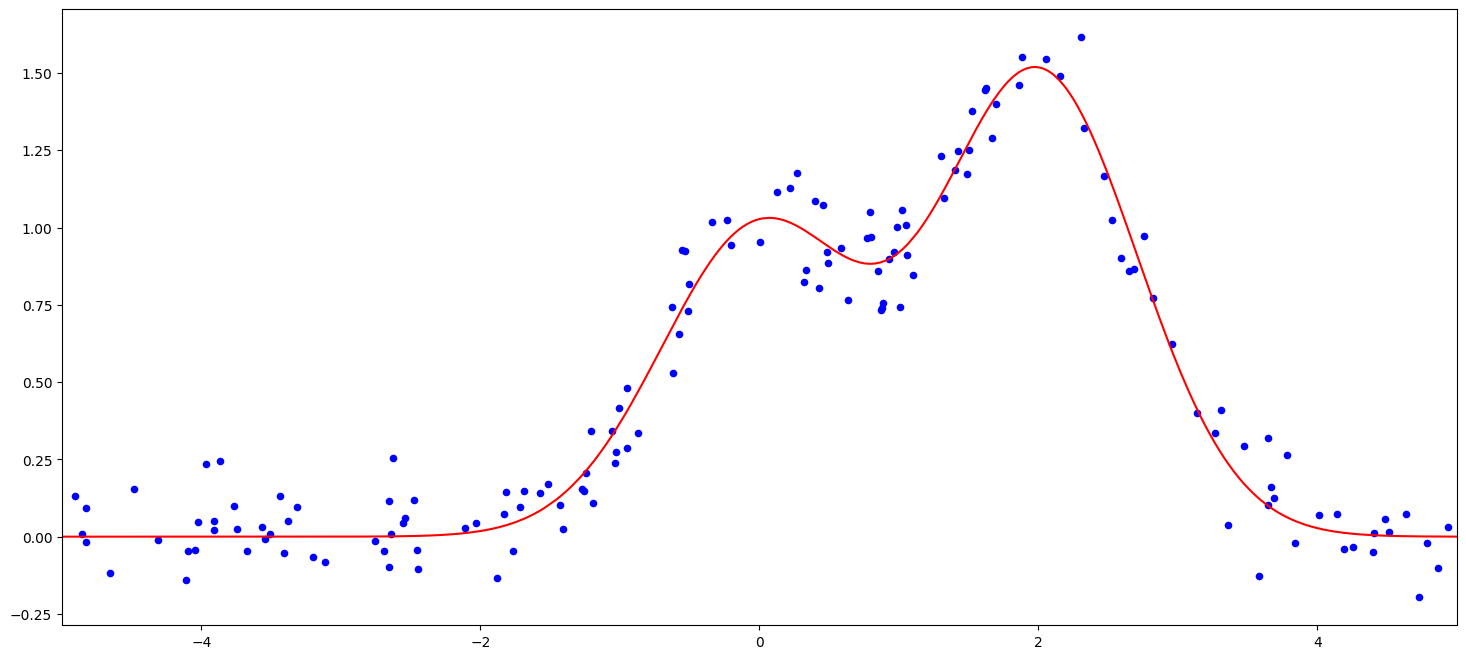

In [62]:
plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5, 5])
     

Text(0.5, 1.0, 'Decision tree, MSE = 21.21')

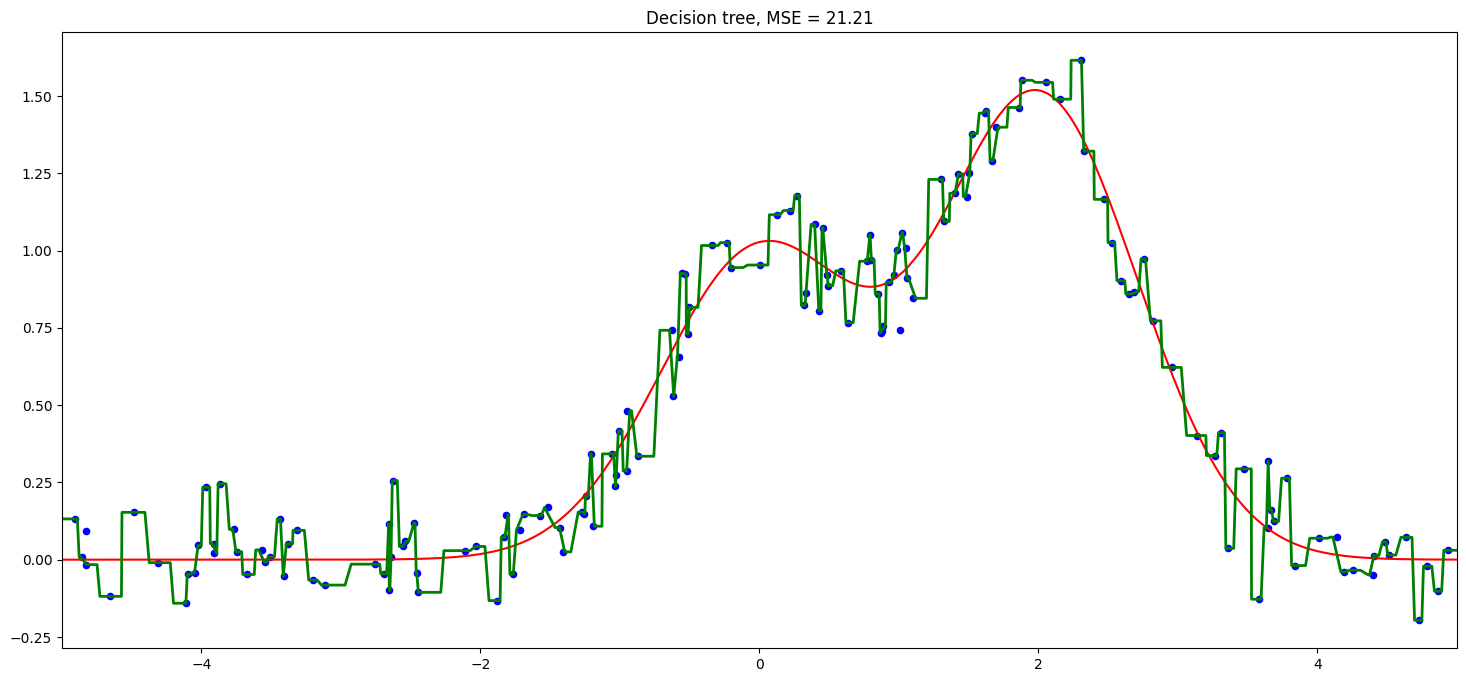

In [63]:

# One decision tree regressor
from sklearn.tree import DecisionTreeRegressor

dtree = DecisionTreeRegressor().fit(X_train, y_train)
d_predict = dtree.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f" 
          % np.sum((y_test - d_predict) ** 2))

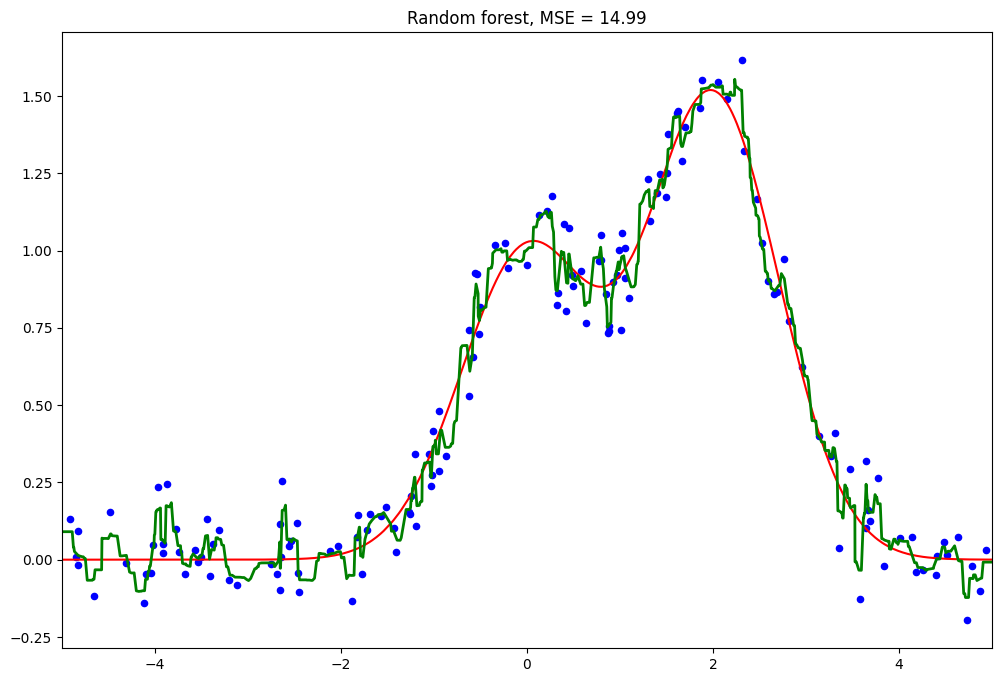

In [65]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=1000).fit(X_train, y_train)
rf_predict = rfr.predict(X_test)

plt.figure(figsize=(12, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2));